In [94]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import config
from data_utils import best_players_plots, table_simulation, expected_stats_vs_actuals, sort_data, colors_config

In [95]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [96]:
data = sort_data(data)
data.head()

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,position,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,was_home,value_ratio
0,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,1,24-25-prem-everton-vs-brighton-&-hove-albion,0,0,43.8,50,1,10,28,513,0.45,4,2,2,82,0.0,1.6,0,33,85,80,421,48,4,0,2,421,0,0,172,0,0,0.4,1,4,0,0,2,0,1.6,0,0.4,82,0,0.0,22.4,5.0,0,0,0,7.0,134,2,0,471,6,2.0,0.1,0.11,2,0,3,2,1,0,0,0,2,0.11,0.11,0,0.0,3,0,0.0,7,0,0,0,0,0,0,4,29,0,0,0.0,513,0,MID,0.0,0.120732,0.120732,0.493902,False,0.4
1,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,2,24-25-prem-brighton-&-hove-albion-vs-mancheste...,2,0,66.2,0,1,22,22,2267,1.77,3,1,0,73,0.0,2.0,1,0,73,75,1548,42,1,1,2,635,2,0,177,0,1,0.4,1,12,0,0,0,0,1.0,1,0.8,73,0,0.16,28.6,5.0,0,0,0,10.7,134,2,0,448,6,2.0,0.1,0.15,1,0,3,6,0,0,0,2,4,0.31,0.04,0,0.0,1,0,0.0,7,0,1,0,0,0,0,3,100,100,0,0.16,1189,0,MID,0.19726,0.049315,0.382192,2.182192,True,0.4
2,Milner,James,Milner,d,Brighton,Midfielder,2425,15157,36,3,24-25-prem-arsenal-vs-brighton-&-hove-albion,0,0,66.3,0,1,24,2,4199,1.98,0,1,0,17,0.0,0.7,0,0,100,0,4535,4,0,1,1,1998,0,0,185,0,0,0.3,1,12,0,0,0,0,1.7,0,1.0,17,0,0.16,28.6,5.0,75,0,0,10.7,134,0,0,461,6,1.7,0.1,0.15,0,0,3,0,0,0,0,0,5,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,472,0,MID,0.0,0.0,1.641176,10.482353,False,0.2
3,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,38,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,0,0,66.3,0,8,27,0,5014,1.98,0,0,0,93,0.0,0.0,0,0,0,0,10991,1,0,0,1,0,0,0,192,0,0,0.0,0,12,0,0,0,0,0.0,0,1.2,1,0,0.16,28.6,5.0,100,0,0,10.7,134,0,0,586,6,0.2,0.0,0.15,0,93,3,1,0,0,0,0,6,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,0,0,MID,0.0,0.0,27.9,178.2,False,0.2
4,Milner,James,Milner,a,Brighton,Midfielder,2526,15157,36,1,25-26-prem-brighton-hove-albion-vs-fulham,0,0,0.1,0,5,3,1,14413,0.24,0,0,0,90,0.0,0.0,0,0,0,0,20304,1,0,0,1,497,0,0,283,0,1,0.0,0,0,0,0,0,0,-0.5,0,3.1,2,0,0.0,0.0,4.9,100,0,-1,0.0,170,0,0,467,1,0.0,0.1,0.0,0,0,3,0,0,0,0,0,1,0.0,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,113,0,MID,0.0,0.0,0.0,10.8,True,0.204082


In [97]:
data.describe()

,season_id,player_code_id,team_code_id,gw_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,value_ratio
count,20820.000000,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0,20820.0
mean,2469.887272,301074.893804,29.317483,17.62219,3.06537,0.323103,92.704894,18.656532,7.149039,102.90586,23.573967,376221.950768,9.061774,2.247454,3.180451,0.445437,79.525216,0.090592,2.501619,0.681124,20.07805,48.085735,26.804899,344997.616571,40.626273,1.047214,0.518252,2.771182,17870.061095,1.595149,0.356004,272.89755,0.088809,1.150528,0.467848,0.703939,84.253074,0.001345,1.942171,0.233045,0.053506,2.448934,0.280836,7.160384,63.441066,0.470509,0.879756,133.394361,5.322344,53.647935,0.006388,-0.796974,31.010754,351.394669,1.658742,-0.007205,250.95903,5.573343,2.515283,4.089073,0.569619,0.271518,12.18439,3.198415,3.415034,1.3183,0.933718,0.00586,0.769356,24.182181,1.44928,0.058634,19.477378,0.001589,0.605043,0.091739,0.090158,6.408165,1.397262,0.449952,0.825648,0.09121,0.187608,0.037656,3.181172,6.191547,13.004851,0.063593,0.091703,21853.710615,53.700768,0.189629,0.107882,4.034388,25.603813,0.519649
std,50.188328,163851.700977,28.123751,10.161679,2.737539,0.86667,158.420643,35.591371,2.039413,140.075446,19.86264,966366.680078,12.013223,2.219857,2.813213,0.894744,28.115777,0.252401,2.061716,0.970727,33.08661,41.213728,33.064733,864762.527166,26.361247,1.38862,0.863576,2.97912,55605.95839,2.251284,1.622635,194.014554,0.314162,1.139154,0.33761,0.957502,163.700696,0.037937,4.280469,0.569797,0.327898,2.048686,0.606375,5.850291,32.937043,0.808918,1.979746,189.553893,1.258846,49.427137,0.084925,2.160886,46.052318,207.824427,2.24622,0.319177,187.414354,1.252751,1.902622,8.337764,1.064473,0.685957,27.611525,0.760072,3.626471,2.019641,1.414766,0.089102,1.176251,34.097324,2.775254,0.112896,34.3607,0.19373,0.988363,0.461849,0.418624,1.606812,5.707007,0.891836,1.444743,0.329315,0.856459,0.25657,2.750357,19.862274,30.140568,0.257814,0.202985,66141.88749,

In [98]:
data.shape

(20820, 105)

In [99]:
data[~data['match_id'].str.contains('prem', na=False)]

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,position,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,was_home,value_ratio


In [100]:
data = data[data['match_id'].str.contains('prem', na=False, case=False)]


In [101]:
match_id_team_name_map = {'arsenal':'Arsenal',
                          'aston-villa':'Aston Villa',
                          'afc-bournemouth':'Bournemouth',
                          'brentford':'Brentford',
                          'brighton-&-hove-albion':'Brighton',
                          'burnley':'Burnley',
                          'chelsea':'Chelsea',
                          'crystal-palace':'Crystal Palace',
                          'everton':'Everton',
                          'fulham':'Fulham',
                          'ipswich-town':'Ipswich',
                          'leeds-united':'Leeds',
                          'leicester-city':'Leicester',
                          'liverpool':'Liverpool',
                          'manchester-city':'Man City','manchester-united':'Man Utd','newcastle-united':'Newcastle','nottingham-forest':"Nott'm Forest",'southampton':'Southampton','tottenham-hotspur':'Spurs','sunderland':'Sunderland','west-ham-united':'West Ham','wolverhampton-wanderers':'Wolves'}
data['was_home'] = pd.to_numeric(data['team_name_id'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [102]:
raw_home = data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1]
raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]

'brighton-hove-albion'

In [103]:
match_id_team_name_map[raw_home[~raw_home.isin(match_id_team_name_map.keys())].unique()[0]] = "Brighton"

In [104]:
data['was_home'] = pd.to_numeric(data['team_name_id'] == data['match_id'].str.split('-vs-').str[0].str.split('prem-').str[1].map(match_id_team_name_map))

In [105]:
data.was_home.isna().sum()

np.int64(0)

Text(0, 0.5, 'Liczba graczy')

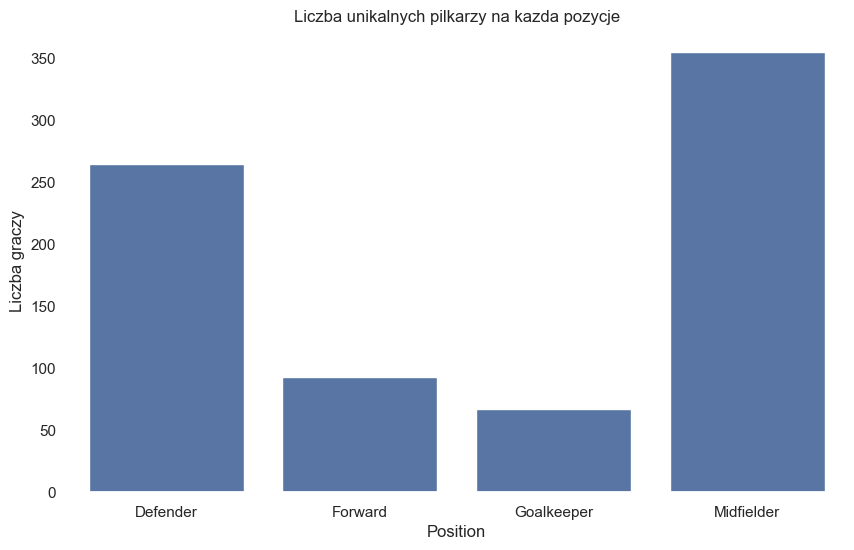

In [106]:
plt.figure(figsize=(10,6))
sns.barplot(data.groupby("position_id")["web_name_id"].nunique())
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [107]:
[c for c in data.columns if "points" in c]

['event_points', 'total_points']

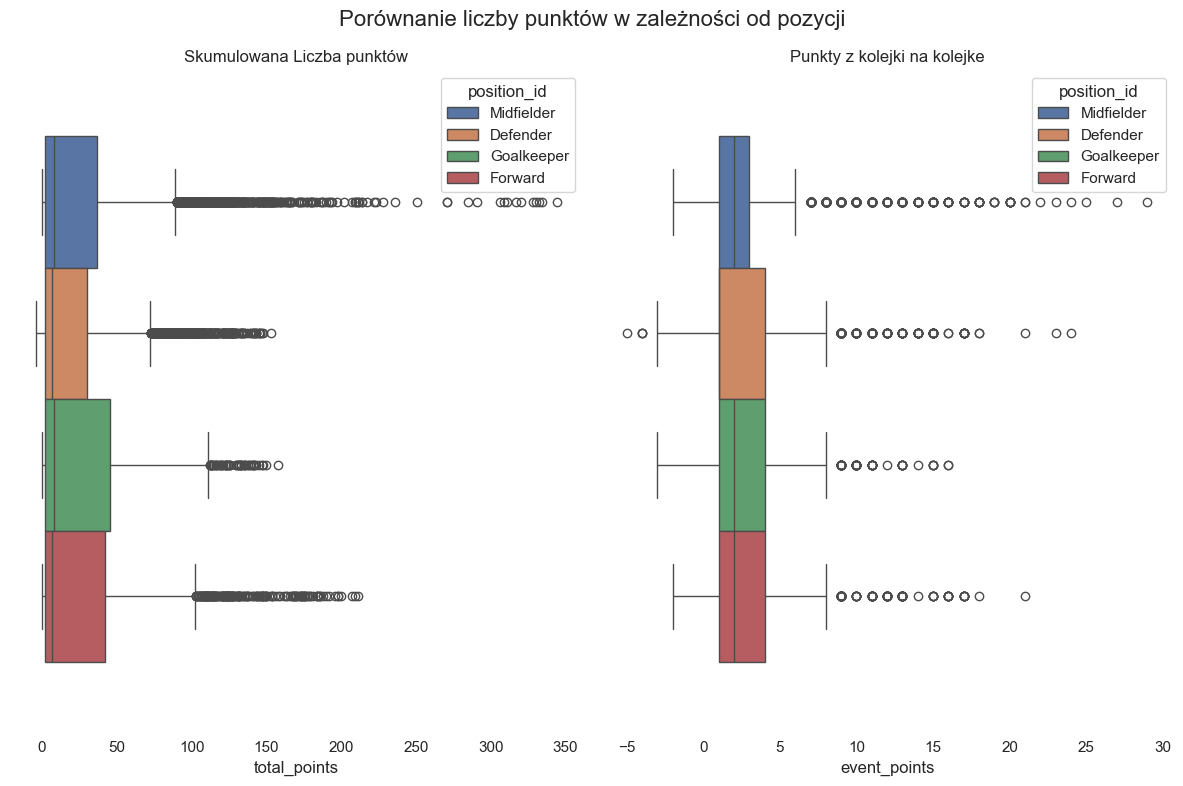

In [108]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

sns.boxplot(data=data, x="total_points", hue="position_id", ax=ax[0])
sns.boxplot(data=data, x="event_points", hue="position_id", ax=ax[1])

ax[0].set_title("Skumulowana Liczba punktów")
ax[1].set_title("Punkty z kolejki na kolejke")
fig.suptitle("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


Text(0.5, 1.0, 'Rozkład Event Points')

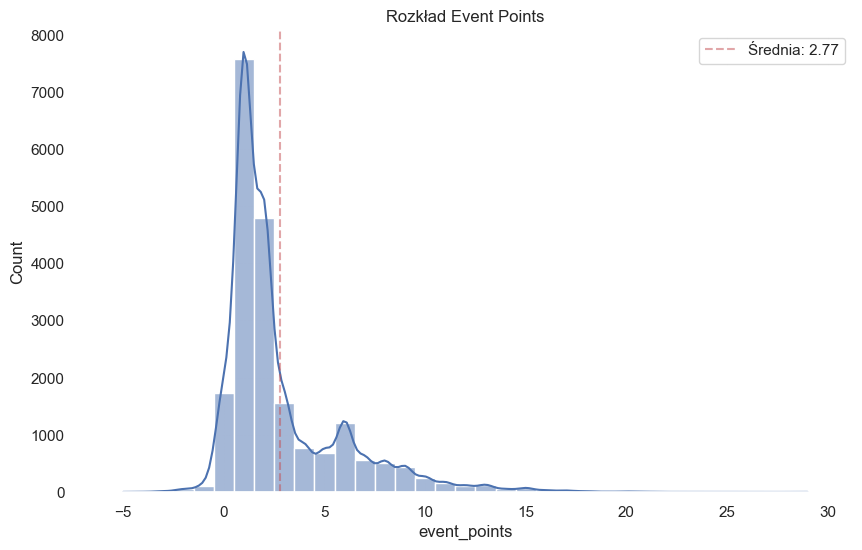

In [109]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.event_points,
             kde=True,
             discrete=True,
             bins=30)
ax.axvline(data.event_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.event_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Event Points")

<Axes: >

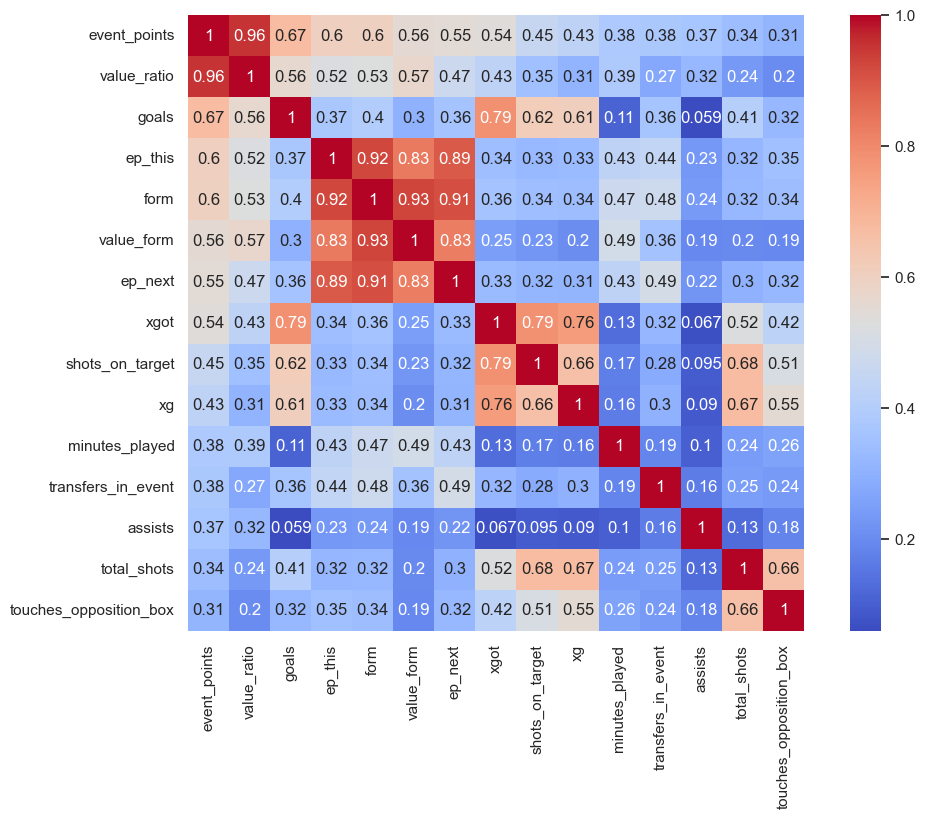

In [110]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["event_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

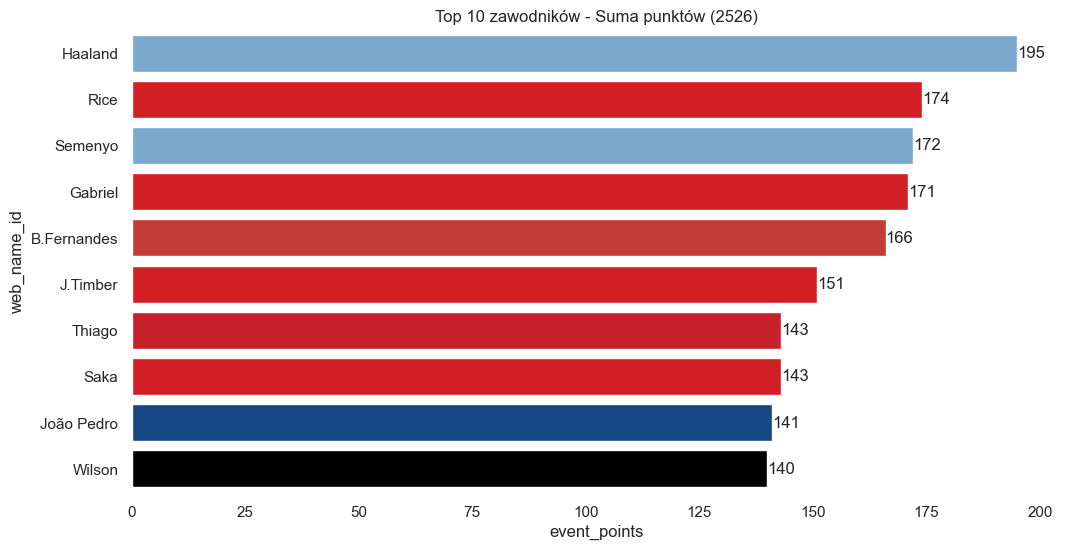

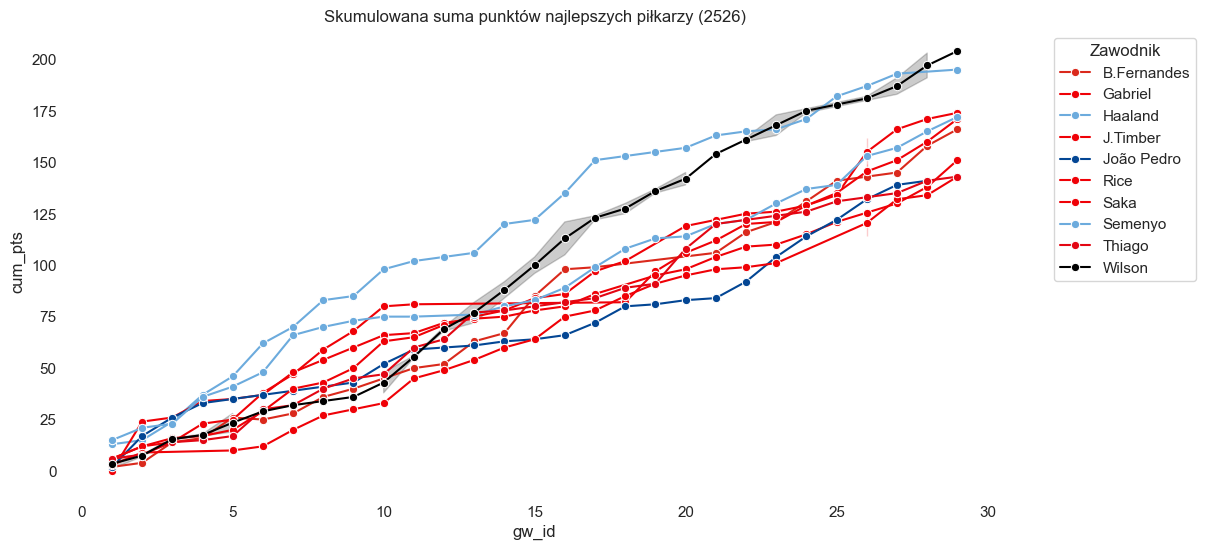

In [111]:
best_players_plots(df=data,
                   num_players=10,
                   season_id=2526)

In [112]:
data["value_ratio"] = (data.event_points / data.now_cost).fillna(0)


In [113]:
data[["web_name_id", "value_ratio", "position_id", "gw_id", "season_id"]].sort_values(by="value_ratio", ascending=False).head()

,web_name_id,value_ratio,position_id,gw_id,season_id
17320,Van de Ven,4.893617,Defender,9,2526
6696,Barnes,4.576271,Midfielder,32,2425
18715,Schade,4.509804,Midfielder,13,2425
12497,Lewis-Potter,4.375,Defender,17,2526
14227,J.Timber,4.363636,Defender,2,2526


In [114]:
x_cols = [c for c in data.columns if "expected" in c]

In [115]:
x_cols

['expected_goals_conceded',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goal_involvements_per_90',
 'expected_goals_conceded_per_90']

In [116]:
data.columns.to_list()[:10]

['web_name_id',
 'first_name_id',
 'second_name_id',
 'status_id',
 'team_name_id',
 'position_id',
 'season_id',
 'player_code_id',
 'team_code_id',
 'gw_id']

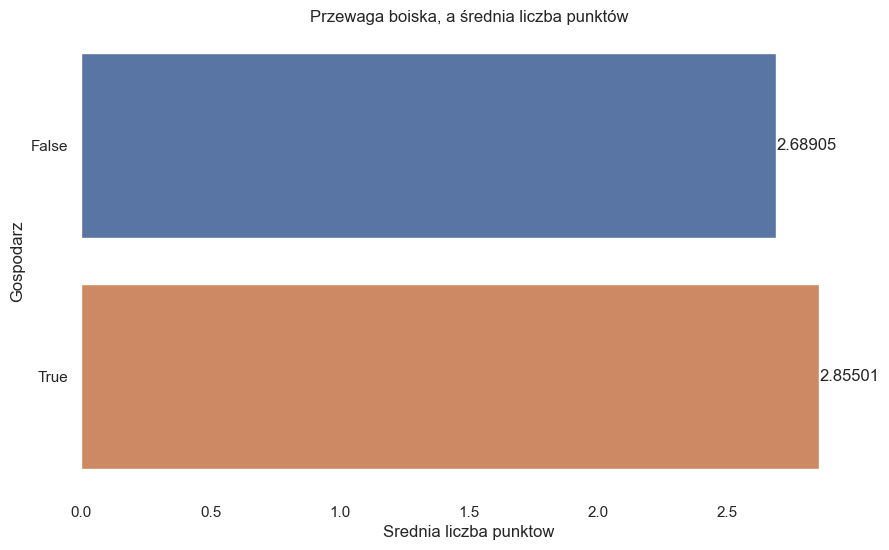

In [117]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="event_points",
    hue="was_home",
    estimator="mean",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [118]:
teams_avenue_form = data.groupby(["season_id", "team_name_id", "was_home"])["event_points"].mean().reset_index()
teams_avenue_form = teams_avenue_form.pivot(index=["season_id", "team_name_id"], columns="was_home", values="event_points")

# Zmień na 1 i 0 jeśli Twoje was_home to zera i jedynki
teams_avenue_form["home_advantage"] = teams_avenue_form[True] - teams_avenue_form[False]

# Zostawiamy nazwy drużyn i sezonu, zamieniając je z powrotem na zwykłe kolumny!
teams_avenue_form.reset_index(inplace=True)

teams_avenue_form.sort_values(by="home_advantage", ascending=False, inplace=True)
teams_avenue_form.columns.name = None

In [119]:
teams_avenue_form.head()

,season_id,team_name_id,False,True,home_advantage
37,2526,Sunderland,2.369099,3.374408,1.005309
33,2526,Man Utd,2.665272,3.45045,0.785178
1,2425,Aston Villa,2.576052,3.314879,0.738827
14,2425,Newcastle,2.800687,3.462069,0.661382
30,2526,Leeds,2.3,2.902041,0.602041


In [120]:
teams_avenue_form.tail()

,season_id,team_name_id,False,True,home_advantage
38,2526,West Ham,2.617284,2.331776,-0.285508
12,2425,Man City,3.426966,3.138298,-0.288668
28,2526,Everton,3.204651,2.91453,-0.290121
18,2425,West Ham,2.541935,2.205298,-0.336637
36,2526,Spurs,3.12381,2.340517,-0.783292


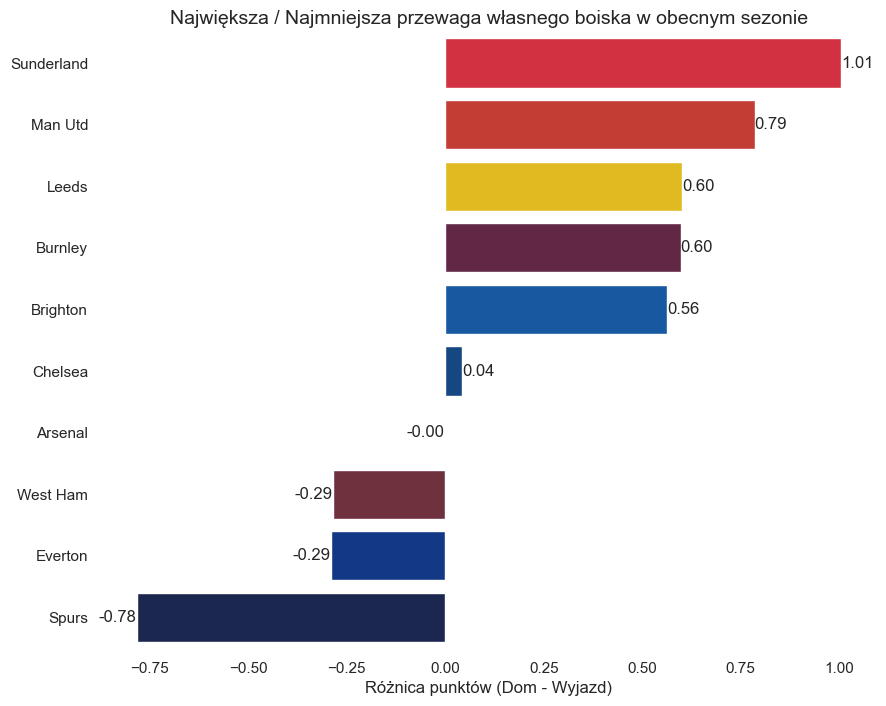

In [121]:
plt.figure(figsize=(10, 8))
ax =sns.barplot(data=pd.concat([teams_avenue_form[teams_avenue_form.season_id==2526].head(), teams_avenue_form[teams_avenue_form.season_id==2526].tail()], axis=0),
            x="home_advantage",
            hue="team_name_id",
            y="team_name_id",
            palette=colors_config.team_colors,
            errorbar=None)
plt.title("Największa / Najmniejsza przewaga własnego boiska w obecnym sezonie", fontsize=14)
plt.xlabel("Różnica punktów (Dom - Wyjazd)")
plt.ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")


In [122]:
team_names = [t for t in data[data.season_id==2526].team_name_id.unique()]
team_names

['Brighton',
 'Everton',
 'Newcastle',
 'Burnley',
 'Bournemouth',
 'Brentford',
 'Crystal Palace',
 'Leeds',
 "Nott'm Forest",
 'Man Utd',
 'Aston Villa',
 'Sunderland',
 'West Ham',
 'Fulham',
 'Wolves',
 'Man City',
 'Liverpool',
 'Chelsea',
 'Arsenal',
 'Spurs']

In [123]:
data[data.season_id==2526].gw_id.unique()

<IntegerArray>
[ 1,  3,  4,  5,  7,  8,  9, 16, 17, 19, 20, 21, 23, 24, 26, 27, 28, 29,  2,
  6, 10, 11, 12, 13, 14, 15, 18, 22, 25]
Length: 29, dtype: Int64

In [124]:
[c for c in data.columns if "sele" in c]

['selected_rank', 'selected_by_percent']

In [125]:
data.position_id.unique()

<ArrowStringArray>
['Midfielder', 'Defender', 'Goalkeeper', 'Forward']
Length: 4, dtype: string

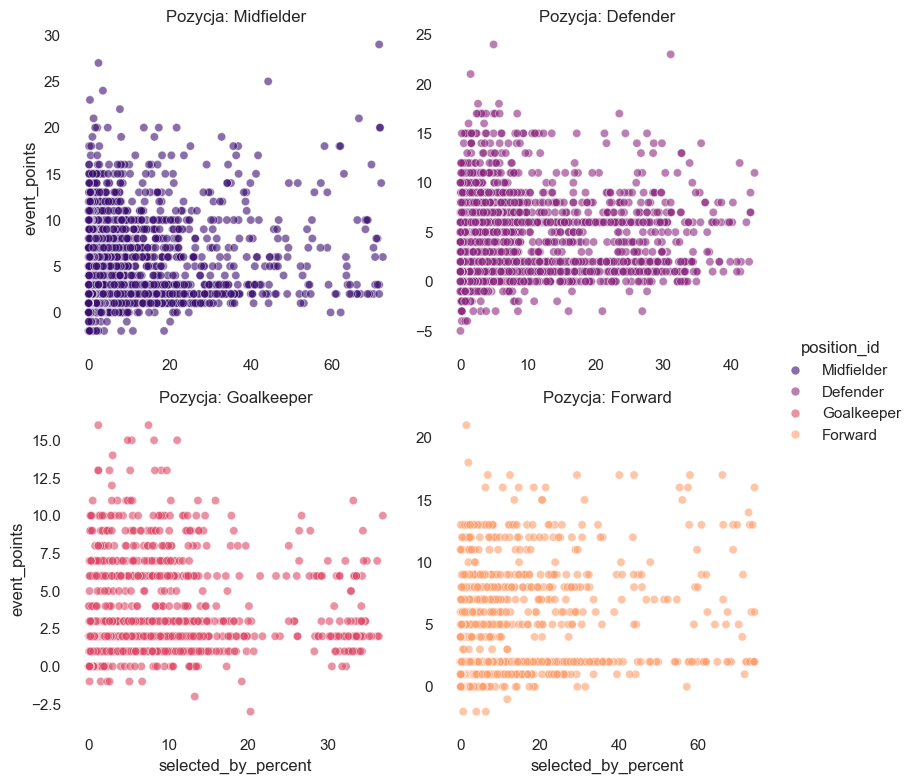

In [126]:
g = sns.relplot(
    data=data,
    x="selected_by_percent",
    y="event_points",
    col="position_id",
    hue="position_id",
    col_wrap=2,
    palette="magma",
    kind="scatter",
    alpha=0.6,
    height=4,
    facet_kws={'sharex': False, 'sharey': False}

)

g.set_titles("Pozycja: {col_name}")

plt.show()

In [127]:
x_cols

['expected_goals_conceded',
 'expected_goals',
 'expected_assists',
 'expected_goal_involvements',
 'expected_goal_involvements_per_90',
 'expected_goals_conceded_per_90']

In [134]:
plt.figure(figsize=(10,6))
random_player = data['web_name_id'].sample(1).iloc[0]

player_stats = data[data['web_name_id'] == random_player][x_cols].mean().reset_index()

player_stats.columns = ['Statystyka', 'Wartość']

fig = px.line_polar(
    data_frame=player_stats,
    r='Wartość',
    theta='Statystyka',
    title=f"Profil radarowy: {random_player}, {data[data['web_name_id'] == random_player].position_id.unique()[0]}"
)
fig.update_traces(fill='toself')


<Figure size 1000x600 with 0 Axes>

In [129]:
"""data.to_parquet(config.TIDY_DATA_PATH)"""

'data.to_parquet(config.TIDY_DATA_PATH)'